# Лабораторная работа №6, Вариант 11

## Цель работы:
Научиться решать задачу классификации методами, решающих деревьев и ансамблей на их основе.

## Задачи:
- освоить метод Random Forest (Случайный лес) - алгоритма машинного
обучения, относящегося к классу ансамблевых методов;
- ценить эффективность алгоритма на практическом примере;
- изучение методов визуализации модели и оценки ее корректности.
    
## Датасет – juice.csv

Набор данных содержит сведения о 1070 покупках, в ходе которых клиент приобрел апельсиновый сок Citrus Hill или Minute Maid. Регистрируется ряд характеристик клиента и продукта.

### Атрибуты:
- **Purchase** – коэффициент с уровнями CH и MM, указывающий, купил ли клиент апельсиновый сок Citrus Hill или Minute Maid (целевая переменная)
- **WeekofPurchase** – неделя с момента покупки
- **StoreID** – идентификатор магазина
- **PriceCH** – цена, взимаемая за CH
- **PriceMM** – цена, взимаемая за ММ
- **DiscCH** – cкидка, предлагаемая для CH
- **DiscMM** – cкидка, предлагаемая для MM
- **SpecialCH** – индикатор специальной цены на CH
- **SpecialMM** – индикатор специальной цены на ММ
- **LoyalCH** – лояльность клиентов к бренду для CH
- **SalePriceMM** – цена продажи ММ
- **SalePriceCH** – цена продажи CH
- **PriceDiff** – разница в ценах, насколько цена ММ меньше продажной цены CH
- **Store7** – коэффициент с уровнями "Нет" и "Да", указывающий, проводится ли продажа в магазине No7
- **PctDiscMM** – процентная скидка для ММ
- **PctDiscCH** – процентная скидка в СН
- **ListPriceDiff** – разница в прейскурантной цене ММ за вычетом прейскурантной цены CH
- **STORE** – в каком из 5 возможных магазинов произошла продажа

## 1. Импорт необходимых библиотек

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay, 
                             roc_curve, auc, precision_recall_curve)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости результатов
np.random.seed(42)

## 2. Загрузка и первичный анализ данных

In [5]:
df = pd.read_csv('juice.csv')

print(f"\nРазмерность данных (строки, столбцы): {df.shape}")

print(f"\nПервые 5 строк датасета:")
print(df.head())

print(f"\nИнформация о типах данных и пропусках:")
print(df.info())

print(f"\nОсновные статистические характеристики:")
print(df.describe().round(2))


Размерность данных (строки, столбцы): (1070, 19)

Первые 5 строк датасета:
   Id Purchase  WeekofPurchase  StoreID  PriceCH  PriceMM  DiscCH  DiscMM  \
0   1       CH             237        1     1.75     1.99    0.00     0.0   
1   2       CH             239        1     1.75     1.99    0.00     0.3   
2   3       CH             245        1     1.86     2.09    0.17     0.0   
3   4       MM             227        1     1.69     1.69    0.00     0.0   
4   5       CH             228        7     1.69     1.69    0.00     0.0   

   SpecialCH  SpecialMM   LoyalCH  SalePriceMM  SalePriceCH  PriceDiff Store7  \
0          0          0  0.500000         1.99         1.75       0.24     No   
1          0          1  0.600000         1.69         1.75      -0.06     No   
2          0          0  0.680000         2.09         1.69       0.40     No   
3          0          0  0.400000         1.69         1.69       0.00     No   
4          0          0  0.956535         1.69         1

## 3. Предобработка данных

In [6]:
# Создание копии данных для преобразований
df_processed = df.copy()

# Кодирование целевой переменной
label_encoder = LabelEncoder()
df_processed['Purchase_encoded'] = label_encoder.fit_transform(df['Purchase'])
print("✓ Целевая переменная закодирована:")
print(f"  MM -> {label_encoder.transform(['MM'])[0]}")
print(f"  CH -> {label_encoder.transform(['CH'])[0]}")

# Преобразование STORE в категориальный тип данных (строковый)
# Хотя в данных STORE может быть числом, это категориальный признак
df_processed['STORE'] = df_processed['STORE'].astype(str)

# Выделение признаков и целевой переменной
X = df_processed.drop(['Purchase', 'Purchase_encoded'], axis=1)
y = df_processed['Purchase_encoded']

# Явное определение категориальных и числовых признаков
# Исходя из описания задачи:
categorical_cols = ['StoreID', 'Store7', 'STORE']  # Категориальные признаки
# Проверяем, существуют ли эти столбцы в данных
categorical_cols = [col for col in categorical_cols if col in X.columns]

# Дополнительно добавляем все строковые колонки
categorical_cols += X.select_dtypes(include=['object']).columns.tolist()
categorical_cols = list(set(categorical_cols))  # Убираем дубликаты

# Числовые признаки - все остальные
numerical_cols = [col for col in X.columns if col not in categorical_cols]

print(f"\nКатегориальные признаки ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"  - {col}: {X[col].nunique()} уникальных значений")

print(f"\nЧисловые признаки ({len(numerical_cols)}):")
print(numerical_cols)

✓ Целевая переменная закодирована:
  MM -> 1
  CH -> 0

Категориальные признаки (3):
  - StoreID: 5 уникальных значений
  - Store7: 2 уникальных значений
  - STORE: 5 уникальных значений

Числовые признаки (15):
['Id', 'WeekofPurchase', 'PriceCH', 'PriceMM', 'DiscCH', 'DiscMM', 'SpecialCH', 'SpecialMM', 'LoyalCH', 'SalePriceMM', 'SalePriceCH', 'PriceDiff', 'PctDiscMM', 'PctDiscCH', 'ListPriceDiff']


### Создание преобразователя для категориальных признаков (One-Hot Encoding)

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

### Разделение данных на обучающую и тестовую выборки

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\n✓ Данные разделены на обучающую и тестовую выборки:")
print(f"  Обучающая выборка: {X_train.shape[0]} записей")
print(f"  Тестовая выборка: {X_test.shape[0]} записей")


✓ Данные разделены на обучающую и тестовую выборки:
  Обучающая выборка: 749 записей
  Тестовая выборка: 321 записей


In [9]:
# Применение преобразований
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Получение имен признаков после One-Hot Encoding
cat_encoder = preprocessor.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols)
all_feature_names = np.concatenate([numerical_cols, cat_feature_names])

print(f"\n✓ Преобразование данных завершено:")
print(f"  Размерность после преобразования: {X_train_processed.shape[1]} признаков")
print(f"  Создано {len(cat_feature_names)} новых признаков через One-Hot Encoding")


✓ Преобразование данных завершено:
  Размерность после преобразования: 24 признаков
  Создано 9 новых признаков через One-Hot Encoding


## 4. Создание и обучение базовой модели Random Forest

In [10]:
base_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # Учитываем дисбаланс классов
)

base_rf.fit(X_train_processed, y_train)

print("Модель Random Forest обучена!")

Модель Random Forest обучена!


## 5. Прогнозирование и оценка модели

In [11]:
y_pred_base = base_rf.predict(X_test_processed)
y_pred_proba_base = base_rf.predict_proba(X_test_processed)[:, 1]

accuracy_base = accuracy_score(y_test, y_pred_base)

print("\n--- БАЗОВАЯ МОДЕЛЬ RANDOM FOREST ---")
print(f"Точность на тестовой выборке: {accuracy_base:.4f}")
print(f"\nОтчет по классификации:")
print(classification_report(y_test, y_pred_base, 
                           target_names=['CH', 'MM']))


--- БАЗОВАЯ МОДЕЛЬ RANDOM FOREST ---
Точность на тестовой выборке: 0.8069

Отчет по классификации:
              precision    recall  f1-score   support

          CH       0.85      0.83      0.84       196
          MM       0.74      0.77      0.76       125

    accuracy                           0.81       321
   macro avg       0.80      0.80      0.80       321
weighted avg       0.81      0.81      0.81       321



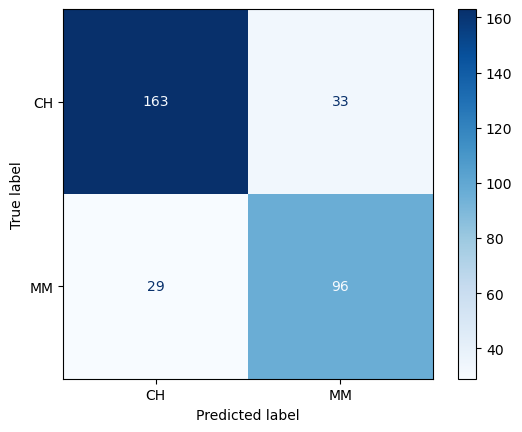

In [12]:
# Визуализация матрицы ошибок
cm = confusion_matrix(y_test, y_pred_base)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['CH', 'MM'])
disp.plot(cmap='Blues')

## 6. Анализ важности признаков

In [13]:
# Получение важности признаков
importances = base_rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Создание DataFrame с важностью признаков
feature_importance_df = pd.DataFrame({
    'Признак': all_feature_names[indices],
    'Важность': importances[indices]
})

print("Топ-15 наиболее важных признаков:")
print(feature_importance_df.head(15).to_string(index=False))

Топ-15 наиболее важных признаков:
       Признак  Важность
       LoyalCH  0.395103
            Id  0.196111
WeekofPurchase  0.082105
     PriceDiff  0.048409
   SalePriceMM  0.032235
 ListPriceDiff  0.030812
   SalePriceCH  0.023084
       PriceCH  0.018489
       PriceMM  0.017905
     PctDiscMM  0.017384
        DiscMM  0.014705
    Store7_Yes  0.014186
     StoreID_7  0.013466
     PctDiscCH  0.011499
     SpecialMM  0.010955


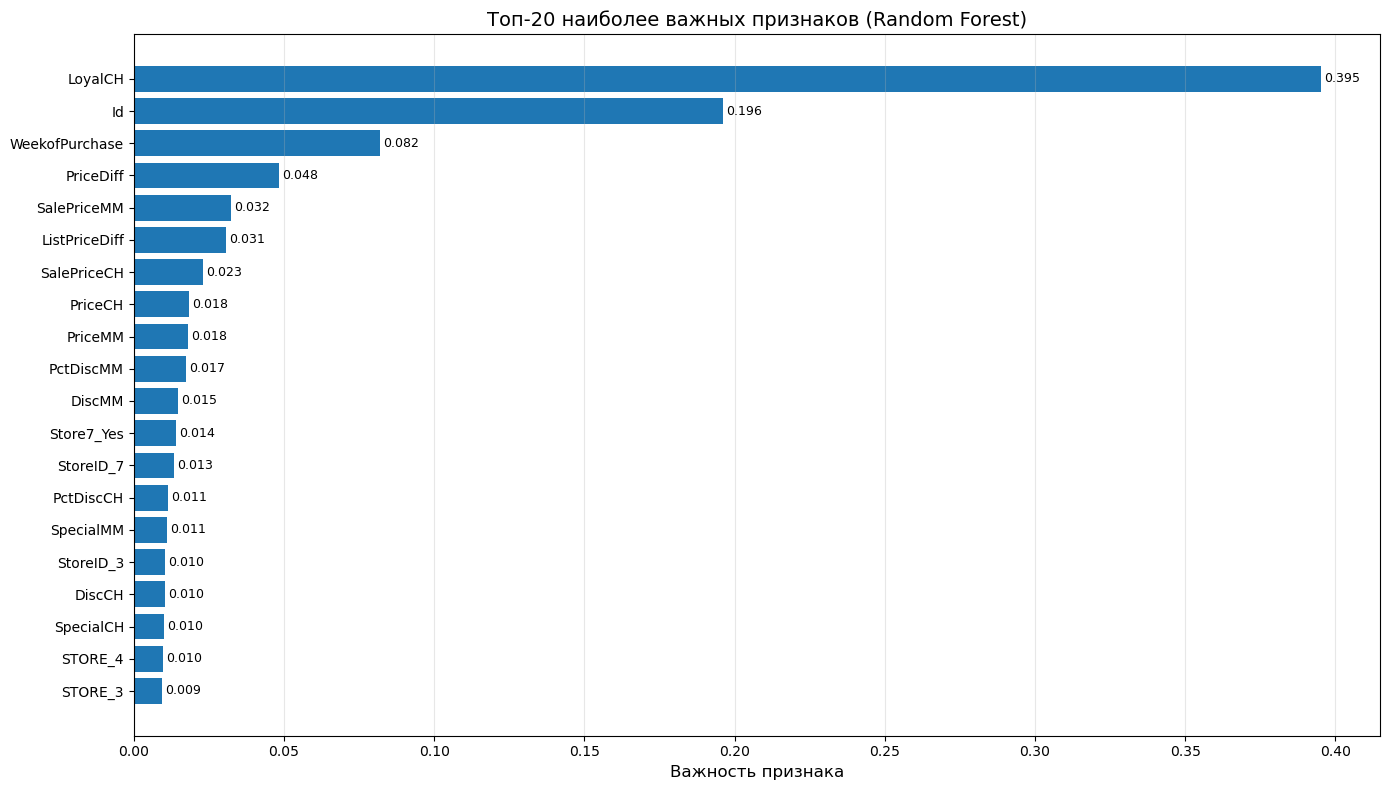

In [14]:
plt.figure(figsize=(14, 8))
top_n = 20
bars = plt.barh(range(top_n), feature_importance_df['Важность'].head(top_n))
plt.yticks(range(top_n), feature_importance_df['Признак'].head(top_n))
plt.xlabel('Важность признака', fontsize=12)
plt.title(f'Топ-{top_n} наиболее важных признаков (Random Forest)', fontsize=14)
plt.gca().invert_yaxis()

# Добавление значений на график
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}', ha='left', va='center', fontsize=9)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
print("\nАнализ важности категориальных признаков (сгруппированных):")

# Группируем важность по исходным категориальным признакам
cat_importance_sum = {}
for feature_name, importance in zip(all_feature_names, importances):
    # Проверяем, является ли признак производным от категориального
    for cat_col in categorical_cols:
        if cat_col in feature_name:
            if cat_col not in cat_importance_sum:
                cat_importance_sum[cat_col] = 0
            cat_importance_sum[cat_col] += importance

cat_importance_df = pd.DataFrame({
    'Категориальный признак': list(cat_importance_sum.keys()),
    'Общая важность': list(cat_importance_sum.values())
}).sort_values('Общая важность', ascending=False)

print(cat_importance_df.to_string(index=False))


Анализ важности категориальных признаков (сгруппированных):
Категориальный признак  Общая важность
               StoreID        0.037218
                 STORE        0.029347
                Store7        0.014186


## 7. Подбор гиперпараметров (Grid Search)

In [16]:
# Определение сетки параметров
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

In [56]:
# Создаем модель для поиска
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Запускаем поиск
grid_search.fit(X_train_processed, y_train)

Fitting 5 folds for each of 648 candidates, totalling 3240 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2', None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy', verbose=1)

In [57]:
# Вывод результатов
print("✓ Подбор гиперпараметров завершен")
print(f"\nЛучшие параметры:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nЛучшая точность при кросс-валидации: {grid_search.best_score_:.4f}")

✓ Подбор гиперпараметров завершен

Лучшие параметры:
  bootstrap: True
  max_depth: 10
  max_features: sqrt
  min_samples_leaf: 2
  min_samples_split: 10
  n_estimators: 50

Лучшая точность при кросс-валидации: 0.8264


In [58]:
# Оценка лучшей модели на тестовых данных
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_processed)
y_pred_proba_best = best_rf.predict_proba(X_test_processed)[:, 1]
accuracy_best = accuracy_score(y_test, y_pred_best)

print(f"\nТочность улучшенной модели на тестовой выборке: {accuracy_best:.4f}")
print(f"Улучшение точности: {(accuracy_best - accuracy_base)*100:.2f}%")

print(f"\nОтчет по классификации (улучшенная модель):")
print(classification_report(y_test, y_pred_best, 
                           target_names=['CH', 'MM']))


Точность улучшенной модели на тестовой выборке: 0.8349
Улучшение точности: 3.43%

Отчет по классификации (улучшенная модель):
              precision    recall  f1-score   support

          CH       0.89      0.84      0.86       196
          MM       0.76      0.83      0.80       125

    accuracy                           0.83       321
   macro avg       0.83      0.83      0.83       321
weighted avg       0.84      0.83      0.84       321

